In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
data = []
labels = []

dataset_path = "leapGestRecog/leapGestRecog"

count = 0
max_images = 5000

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if os.path.isdir(person_path):

        for gesture in os.listdir(person_path):

            gesture_path = os.path.join(person_path, gesture)

            if os.path.isdir(gesture_path):

                for image in os.listdir(gesture_path):

                    img_path = os.path.join(gesture_path, image)

                    img = cv2.imread(img_path)

                    if img is not None:

                        img = cv2.resize(img, (64, 64))

                        data.append(img)
                        labels.append(gesture)

                        count += 1

                        if count % 1000 == 0:
                            print("Loaded:", count)

                        if count >= max_images:
                            break

                if count >= max_images:
                    break

        if count >= max_images:
            break

print("Total Images:", len(data))

Loaded: 1000
Loaded: 2000
Loaded: 3000
Loaded: 4000
Loaded: 5000
Total Images: 5000


In [3]:
data = np.array(data, dtype=np.float32) / 255.0
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)

Data Shape: (5000, 64, 64, 3)
Labels Shape: (5000,)


In [4]:
encoder = LabelEncoder()

labels = encoder.fit_transform(labels)

labels = to_categorical(labels)

print("Total Classes:", len(encoder.classes_))
print(encoder.classes_)

Total Classes: 10
['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (4000, 64, 64, 3)
Testing Shape: (1000, 64, 64, 3)


In [6]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(labels.shape[1], activation='softmax'))

C:\Users\saisr\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 177ms/step - accuracy: 0.8643 - loss: 0.4480 - val_accuracy: 0.9990 - val_loss: 0.0063
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.9915 - loss: 0.0306 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.9948 - loss: 0.0195 - val_accuracy: 1.0000 - val_loss: 6.4738e-04
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - accuracy: 0.9967 - loss: 0.0126 - val_accuracy: 0.9980 - val_loss: 0.0087
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.9970 - loss: 0.0119 - val_accuracy: 0.9970 - val_loss: 0.0030
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9962 - loss: 0.0152 - val_accuracy: 1.0000 - val_loss: 9.5130e-05
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - accuracy: 0.9998 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 6.0776e-05
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.99

In [9]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy * 100)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 2.9909e-05
Accuracy: 100.0


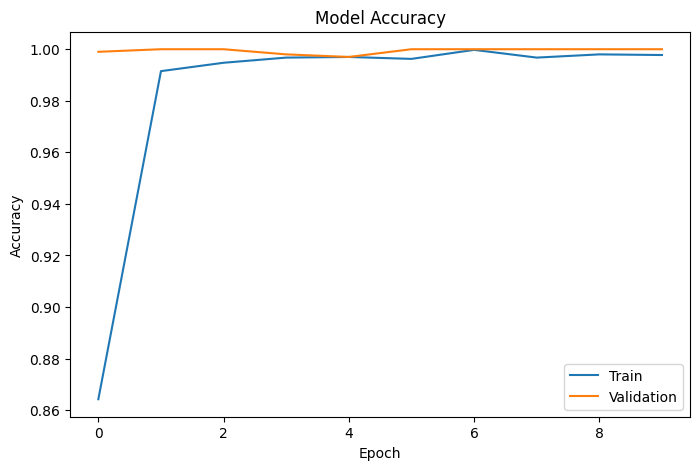

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

In [11]:
model.save("gesture_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
